# Enhancing Maternal Health Risk Classification through Adamax-Optimized Multilayer Perceptron with Early Stopping and Interpretable Feature Analysis

**Tyas Nur Kumala — 1301213030**  
Informatics Undergraduate Program, Faculty of Informatics, Telkom University

---
## 1. Library Installation

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow imbalanced-learn joblib shap


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 2. Import Libraries & Set Random Seed (Reproducibility)

In [2]:

# SET ALL RANDOM SEEDS — ENSURES REPRODUCIBLE RESULT
import os
import random
import numpy as np

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

print(f"All random seeds set to: {SEED}")
print(f"TensorFlow version: {tf.__version__}")

# Core libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Sklearn — preprocessing & evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve, auc
)

# Sklearn — baseline models
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Imbalanced learn
from imblearn.over_sampling import SMOTE

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

# SHAP
import shap

print("\nAll libraries successfully imported!")

All random seeds set to: 42
TensorFlow version: 2.21.0

All libraries successfully imported!


---
## 3. Load Dataset

In [3]:
df = pd.read_csv("Dataset - Updated.csv")
print("Initial dataset shape:", df.shape)
print()
df.head()

Initial dataset shape: (1205, 12)



,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low


---
## 4. Exploratory Data Analysis (EDA)

In [4]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1205 non-null   int64  
 1   Systolic BP             1200 non-null   float64
 2   Diastolic               1201 non-null   float64
 3   BS                      1203 non-null   float64
 4   Body Temp               1205 non-null   int64  
 5   BMI                     1187 non-null   float64
 6   Previous Complications  1203 non-null   float64
 7   Preexisting Diabetes    1203 non-null   float64
 8   Gestational Diabetes    1205 non-null   int64  
 9   Mental Health           1205 non-null   int64  
 10  Heart Rate              1203 non-null   float64
 11  Risk Level              1187 non-null   str    
dtypes: float64(7), int64(4), str(1)
memory usage: 113.1 KB


In [5]:
# Descriptive statistics
df.describe().round(3)

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate
count,1205.000,1200.000,1201.000,1203.000,1205.000,1187.000,1203.000,1203.000,1205.000,1205.000,1203.000
mean,27.732,116.819,77.167,7.501,98.396,23.315,0.175,0.288,0.118,0.334,75.817
std,12.571,18.716,14.305,3.050,1.088,3.876,0.380,0.453,0.323,0.472,7.227
min,10.000,70.000,40.000,3.000,97.000,0.000,0.000,0.000,0.000,0.000,58.000
25%,21.000,100.000,65.000,6.000,98.000,20.450,0.000,0.000,0.000,0.000,70.000
50%,25.000,120.000,80.000,6.900,98.000,23.000,0.000,0.000,0.000,0.000,76.000
75%,32.000,130.000,90.000,7.900,98.000,25.000,0.000,1.000,0.000,1.000,80.000
max,325.000,200.000,140.000,19.000,103.000,37.000,1.000,1.000,1.000,1.000,92.000


In [6]:
# Missing values analysis
print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
                        Missing Count  Missing (%)
Systolic BP                         5         0.41
Diastolic                           4         0.33
BS                                  2         0.17
BMI                                18         1.49
Previous Complications              2         0.17
Preexisting Diabetes                2         0.17
Heart Rate                          2         0.17
Risk Level                         18         1.49

Total missing values: 53


Risk Level Distribution:
            Count  Percentage (%)
Risk Level                       
Low           713           60.07
High          474           39.93


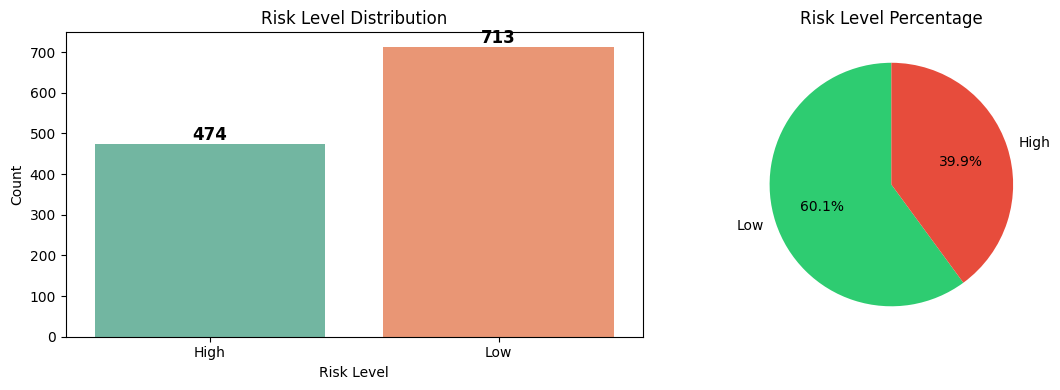

In [7]:
# Target class distribution
print("Risk Level Distribution:")
counts = df['Risk Level'].value_counts()
pcts = df['Risk Level'].value_counts(normalize=True).round(4) * 100
dist_df = pd.DataFrame({'Count': counts, 'Percentage (%)': pcts})
print(dist_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
sns.countplot(x='Risk Level', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Risk Level Distribution')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Risk Level Percentage')

plt.tight_layout()
plt.savefig('risk_level_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Mental Health Distribution:
Mental Health
0    802
1    403
Name: count, dtype: int64


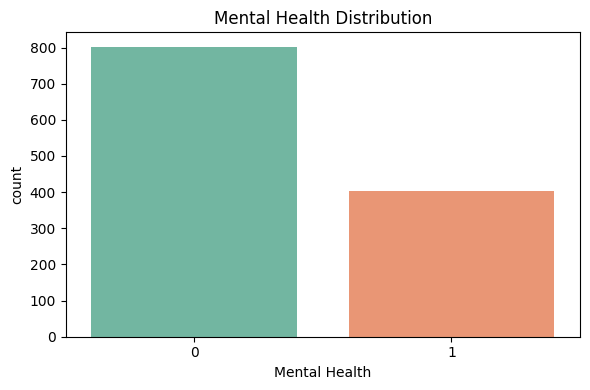

In [8]:
# Mental Health distribution
print("Mental Health Distribution:")
print(df['Mental Health'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='Mental Health', data=df, palette='Set2')
plt.title('Mental Health Distribution')
plt.tight_layout()
plt.show()

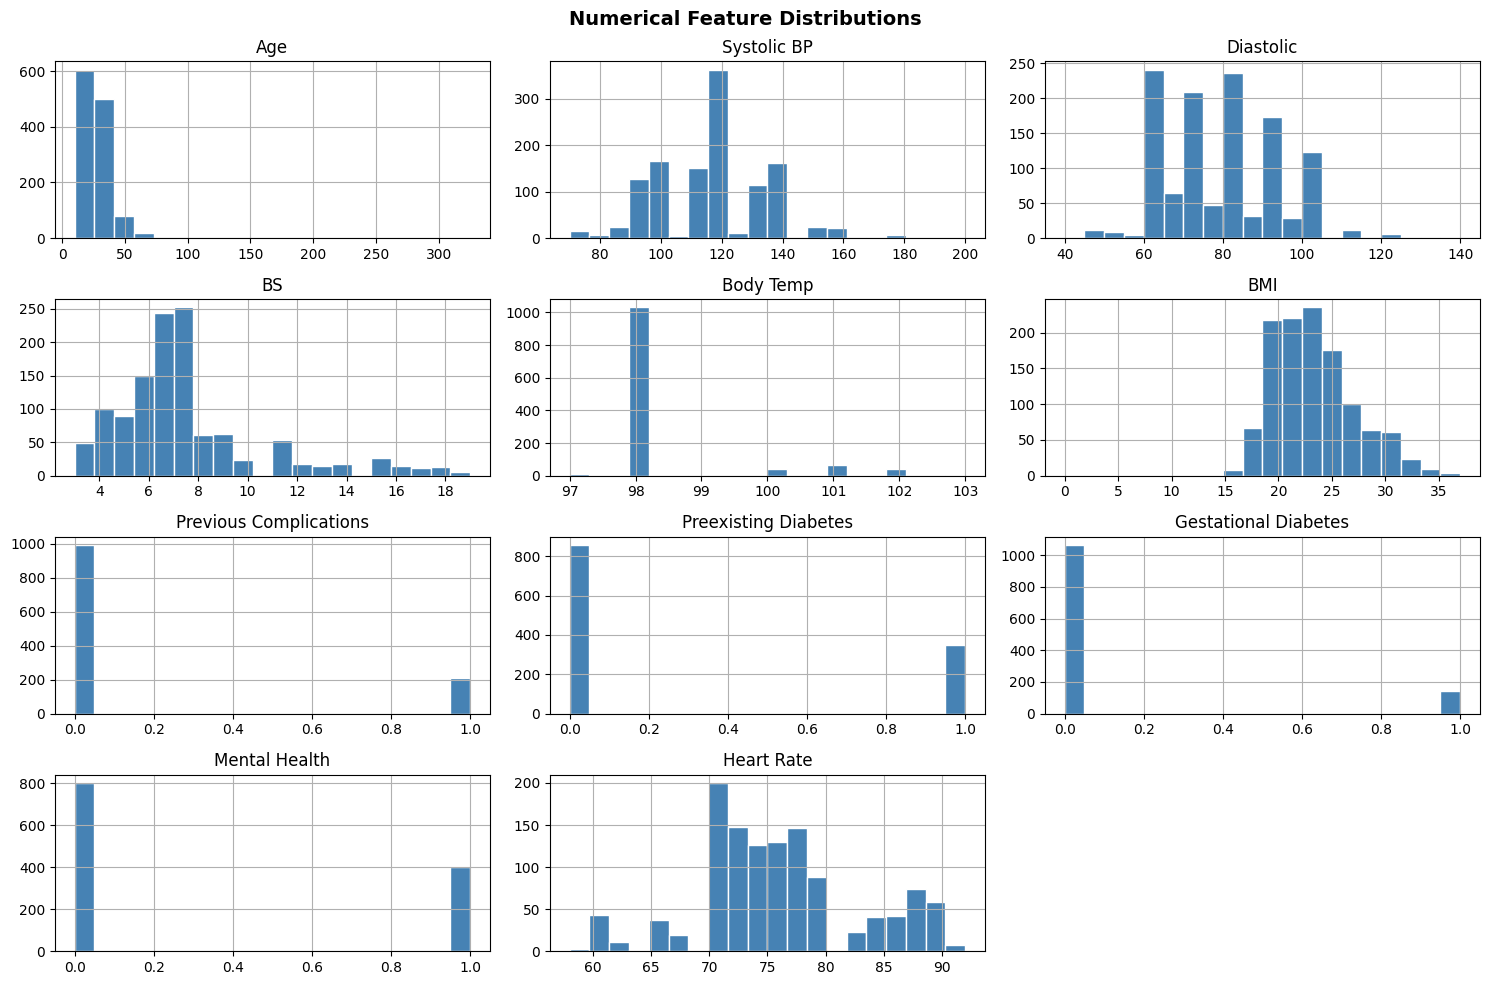

In [9]:
# Numerical feature distributions
numerical_cols = df.select_dtypes(include=np.number).columns
df[numerical_cols].hist(bins=20, figsize=(15, 10), color='steelblue', edgecolor='white')
plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('numerical_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

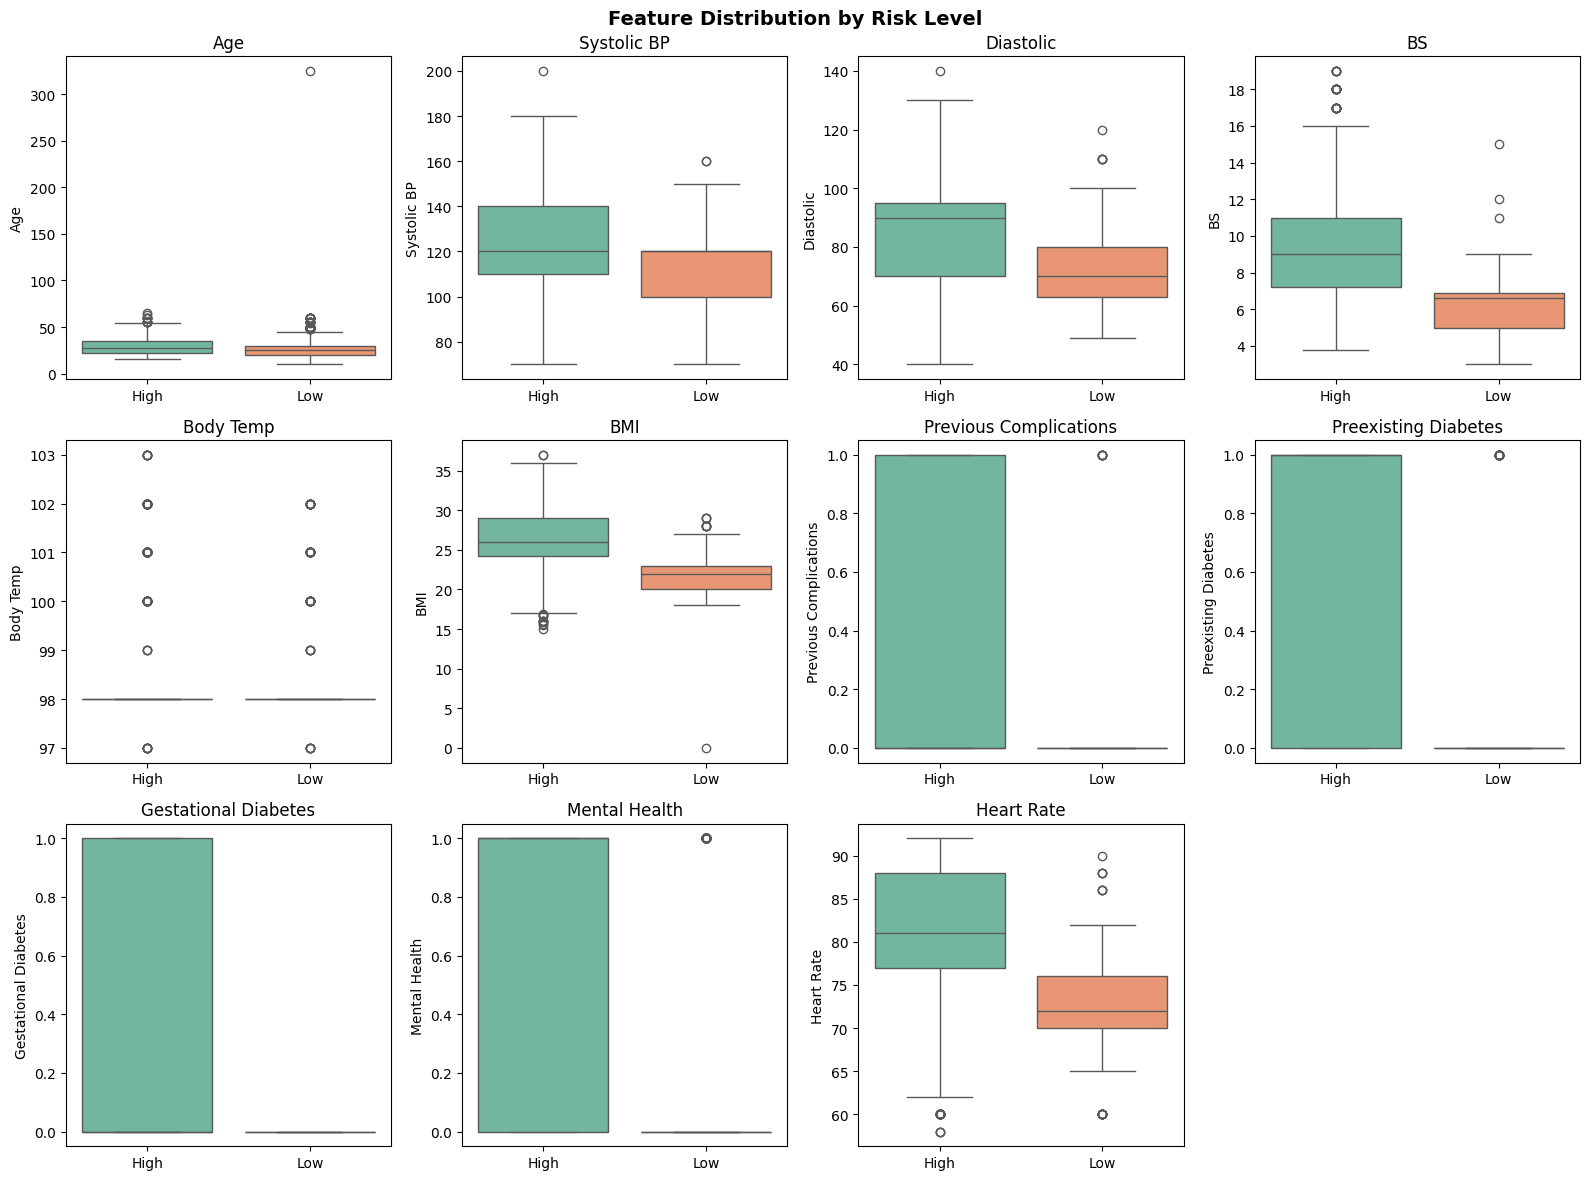

In [10]:
# Box plot per feature by Risk Level
df_temp = df.copy()
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.boxplot(x='Risk Level', y=col, data=df_temp, palette='Set2', ax=axes[i])
        axes[i].set_title(col)
        axes[i].set_xlabel('')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distribution by Risk Level', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_by_risk_level.png', dpi=300, bbox_inches='tight')
plt.show()

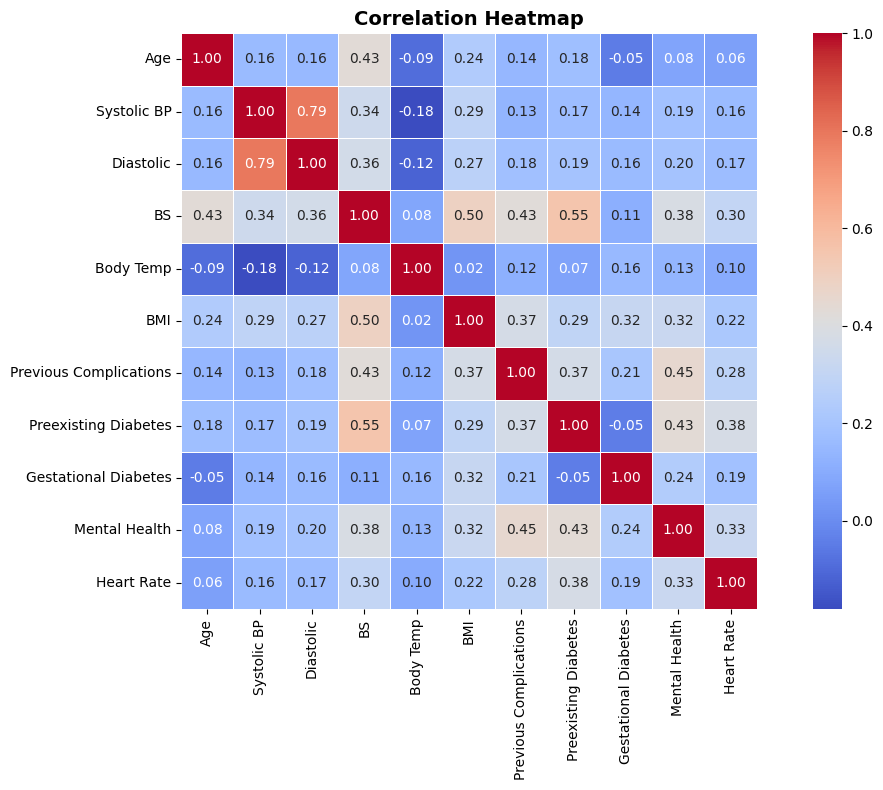

In [11]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 5. Data Preprocessing

In [12]:
# Remove duplicates and missing values
print(f"Shape before cleaning : {df.shape}")
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
print(f"Shape after cleaning  : {df.shape}")
print(f"Total rows removed    : {1205 - len(df)}")

Shape before cleaning : (1205, 12)
Shape after cleaning  : (1148, 12)
Total rows removed    : 57


In [13]:
# Encode target label
le = LabelEncoder()
df['Risk Level'] = le.fit_transform(df['Risk Level'])

print("Classes recognized by LabelEncoder:", le.classes_)
print("Class mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} -> {i}")
print(f"\nNumber of classes: {len(le.classes_)} (Binary Classification)")
print("Distribution after encoding:")
print(pd.Series(df['Risk Level']).value_counts())

Classes recognized by LabelEncoder: ['High' 'Low']
Class mapping:
  High -> 0
  Low -> 1

Number of classes: 2 (Binary Classification)
Distribution after encoding:
Risk Level
1    685
0    463
Name: count, dtype: int64


In [14]:
# Split features and target
X = df.drop('Risk Level', axis=1)
y = df['Risk Level']

print(f"Number of features : {X.shape[1]}")
print(f"Number of samples  : {X.shape[0]}")
print(f"Feature names      : {X.columns.tolist()}")

Number of features : 11
Number of samples  : 1148
Feature names      : ['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Previous Complications', 'Preexisting Diabetes', 'Gestational Diabetes', 'Mental Health', 'Heart Rate']


In [15]:
# Train-validation split (80:20) with stratify
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Validation set : {X_val.shape[0]} samples")
print()
print("Training class distribution:")
print(pd.Series(y_train).value_counts())
print("Validation class distribution:")
print(pd.Series(y_val).value_counts())

Training set   : 918 samples
Validation set : 230 samples

Training class distribution:
Risk Level
1    548
0    370
Name: count, dtype: int64
Validation class distribution:
Risk Level
1    137
0     93
Name: count, dtype: int64


In [16]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Save scaler and label encoder
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("Scaler and LabelEncoder saved successfully!")

Scaler and LabelEncoder saved successfully!


Distribution BEFORE SMOTE:
Risk Level
1    548
0    370
Name: count, dtype: int64

Distribution AFTER SMOTE:
Risk Level
1    548
0    548
Name: count, dtype: int64


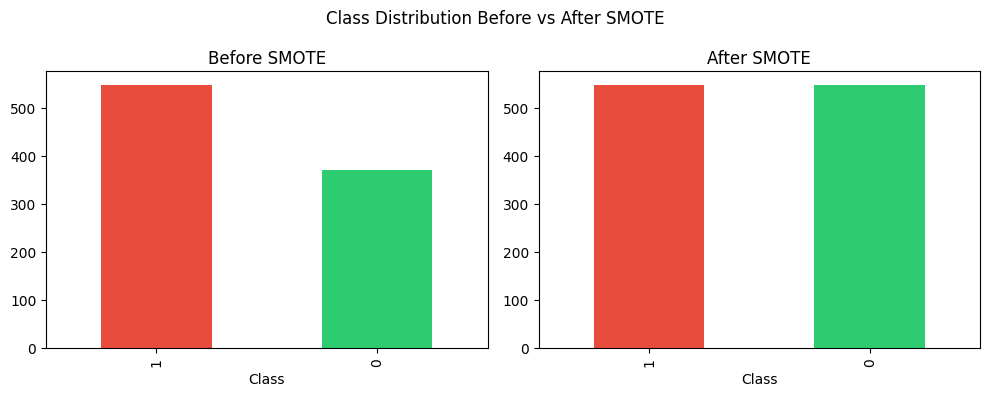

In [17]:
# SMOTE — Oversampling to handle class imbalance
print("Distribution BEFORE SMOTE:")
print(pd.Series(y_train).value_counts())

smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\nDistribution AFTER SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# Visualize before vs after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
pd.Series(y_train).value_counts().plot(
    kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], title='Before SMOTE')
pd.Series(y_train_smote).value_counts().plot(
    kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71'], title='After SMOTE')
axes[0].set_xlabel('Class')
axes[1].set_xlabel('Class')
plt.suptitle('Class Distribution Before vs After SMOTE')
plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.2405405405405405), 1: np.float64(0.8375912408759124)}


---
## 6. Helper Functions

In [19]:
target_names = le.classes_
results     = {}   # Store accuracy for all models
results_auc = {}   # Store AUC for all models
results_fn  = {}   # Store False Negative (High Risk) for all models


def evaluate_model(name, y_true, y_pred, y_prob, target_names, save_prefix):
    """
    Comprehensive model evaluation.
    Computes: Accuracy, AUC, Classification Report,
              Confusion Matrix, and False Negative Analysis.
    """
    print(f"\n{'='*65}")
    print(f"  MODEL: {name}")
    print(f"{'='*65}")

    # Classification Report
    report = classification_report(y_true, y_pred, target_names=target_names)
    print("\nClassification Report:")
    print(report)

    # Save report
    with open(f'{save_prefix}_classification_report.txt', 'w') as f:
        f.write(f"Classification Report — {name}\n\n")
        f.write(report)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names,
                linewidths=1)
    plt.title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    # False Negative Analysis (Clinical Impact)
    # High = class 0 (after LabelEncoder: High=0, Low=1)
    # cm.ravel() with High=0 (negative class), Low=1 (positive class):
    #   tn = True High → Pred High  (correctly detected)
    #   fp = True High → Pred Low   ← HIGH RISK MISSED (clinically dangerous!)
    #   fn = True Low  → Pred High  (false alarm)
    #   tp = True Low  → Pred Low   (correctly detected)
    tn, fp, fn, tp = cm.ravel()

    # High Risk missed = fp (True High predicted as Low)
    high_risk_missed = fp
    total_high_risk  = tn + fp   # all actual High Risk cases
    fnr = high_risk_missed / total_high_risk if total_high_risk > 0 else 0

    print(f"  True High detected (correctly)           : {tn}")
    print(f"  False Negative (High Risk missed)        : {high_risk_missed}  ← Clinically DANGEROUS!")
    print(f"  False Negative Rate (High Risk)          : {fnr:.4f} ({fnr*100:.2f}%)")
    print(f"  [Note] Low Risk misclassified as High    : {fn}  (false alarm, not dangerous)")

    # AUC Score
    auc_score = roc_auc_score(y_true, y_prob)
    print(f"  AUC Score                                : {auc_score:.4f}")

    acc = accuracy_score(y_true, y_pred)
    print(f"  Accuracy                                 : {acc:.4f}")

    return acc, auc_score, high_risk_missed


def plot_history(history, title_prefix, save_prefix):
    """Plot training accuracy and loss curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='Train Acc',
                 linewidth=2, color='#3498db')
    axes[0].plot(history.history['val_accuracy'], label='Val Acc',
                 linewidth=2, color='#e67e22')
    axes[0].set_title(f'{title_prefix}\nModel Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train Loss',
                 linewidth=2, color='#3498db')
    axes[1].plot(history.history['val_loss'], label='Val Loss',
                 linewidth=2, color='#e67e22')
    axes[1].set_title(f'{title_prefix}\nModel Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{save_prefix}_training_curve.png', dpi=300, bbox_inches='tight')
    plt.show()


def save_history(history, filename):
    """Save training history to txt file."""
    with open(filename, 'w') as f:
        for i in range(len(history.history['loss'])):
            f.write(f"Epoch {i+1}\n")
            f.write(f"accuracy: {history.history['accuracy'][i]:.4f}\n")
            f.write(f"loss: {history.history['loss'][i]:.4f}\n")
            f.write(f"val_accuracy: {history.history['val_accuracy'][i]:.4f}\n")
            f.write(f"val_loss: {history.history['val_loss'][i]:.4f}\n\n")
        f.write("=== FINAL RESULT ===\n")
        f.write(f"Final Train Accuracy: {history.history['accuracy'][-1]:.4f}\n")
        f.write(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}\n")
    print(f"Training history saved: {filename}")


def build_mlp(optimizer, input_dim, num_classes=2):
    """
    Build MLP model.
    OUTPUT LAYER: Dense(2) — CORRECT for binary classification (High/Low)
    """
    model = Sequential([
        Dense(128, activation='relu',
              input_shape=(input_dim,),
              kernel_regularizer=regularizers.l2(0.01)),
        Dropout(0.5),
        Dense(64, activation='relu',
              kernel_regularizer=regularizers.l2(0.01)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def evaluate_mlp(model, X_val, y_val, target_names, name, save_prefix):
    """Comprehensive MLP model evaluation."""
    y_pred_probs  = model.predict(X_val)
    y_pred_labels = np.argmax(y_pred_probs, axis=1)
    y_prob_pos    = y_pred_probs[:, 1]   # probability of positive class (Low=1)
    acc, auc_score, high_risk_missed = evaluate_model(
        name, y_val, y_pred_labels, y_prob_pos, target_names, save_prefix
    )
    return acc, auc_score, high_risk_missed


print("All helper functions defined successfully!")
print(f"Input dimension : {X_train_scaled.shape[1]} features")
print(f"Output classes  : {len(le.classes_)} ({le.classes_.tolist()})")

All helper functions defined successfully!
Input dimension : 11 features
Output classes  : 2 (['High', 'Low'])


---
## 7. Baseline Models


  MODEL: Decision Tree

Classification Report:
              precision    recall  f1-score   support

        High       0.98      0.94      0.96        93
         Low       0.96      0.99      0.97       137

    accuracy                           0.97       230
   macro avg       0.97      0.96      0.96       230
weighted avg       0.97      0.97      0.97       230



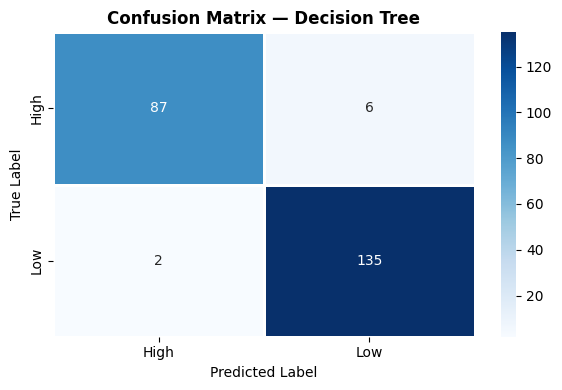

  True High detected (correctly)           : 87
  False Negative (High Risk missed)        : 6  ← Clinically DANGEROUS!
  False Negative Rate (High Risk)          : 0.0645 (6.45%)
  [Note] Low Risk misclassified as High    : 2  (false alarm, not dangerous)
  AUC Score                                : 0.9604
  Accuracy                                 : 0.9652
  10-Fold CV: 0.9630 ± 0.0201


In [20]:

# Decisio
dt = DecisionTreeClassifier(random_state=SEED)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_val_scaled)
y_prob_dt = dt.predict_proba(X_val_scaled)[:, 1]
acc_dt, auc_dt, fn_dt = evaluate_model(
    'Decision Tree', y_val, y_pred_dt, y_prob_dt, target_names, 'dt'
)
results['Decision Tree']     = acc_dt
results_auc['Decision Tree'] = auc_dt
results_fn['Decision Tree']  = fn_dt

# K-Fold Cross Validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
cv_dt = cross_val_score(dt, X_train_scaled, y_train, cv=kf, scoring='accuracy')
print(f"  10-Fold CV: {cv_dt.mean():.4f} ± {cv_dt.std():.4f}")


  MODEL: Naive Bayes

Classification Report:
              precision    recall  f1-score   support

        High       0.98      0.89      0.93        93
         Low       0.93      0.99      0.96       137

    accuracy                           0.95       230
   macro avg       0.95      0.94      0.95       230
weighted avg       0.95      0.95      0.95       230



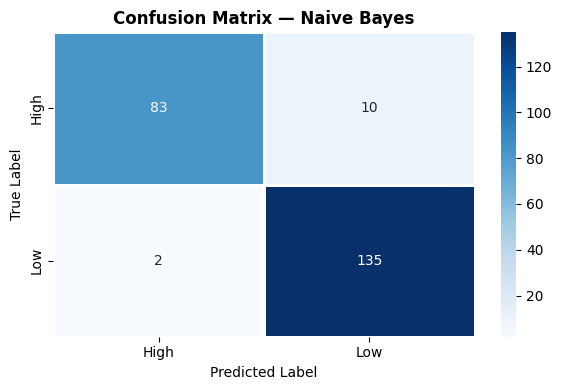

  True High detected (correctly)           : 83
  False Negative (High Risk missed)        : 10  ← Clinically DANGEROUS!
  False Negative Rate (High Risk)          : 0.1075 (10.75%)
  [Note] Low Risk misclassified as High    : 2  (false alarm, not dangerous)
  AUC Score                                : 0.9932
  Accuracy                                 : 0.9478
  10-Fold CV: 0.9477 ± 0.0212


In [21]:

# Naive Bayes

nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_val_scaled)
y_prob_nb = nb.predict_proba(X_val_scaled)[:, 1]
acc_nb, auc_nb, fn_nb = evaluate_model(
    'Naive Bayes', y_val, y_pred_nb, y_prob_nb, target_names, 'nb'
)
results['Naive Bayes']     = acc_nb
results_auc['Naive Bayes'] = auc_nb
results_fn['Naive Bayes']  = fn_nb

cv_nb = cross_val_score(nb, X_train_scaled, y_train, cv=kf, scoring='accuracy')
print(f"  10-Fold CV: {cv_nb.mean():.4f} ± {cv_nb.std():.4f}")


  MODEL: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.94      0.95        93
         Low       0.96      0.98      0.97       137

    accuracy                           0.96       230
   macro avg       0.96      0.96      0.96       230
weighted avg       0.96      0.96      0.96       230



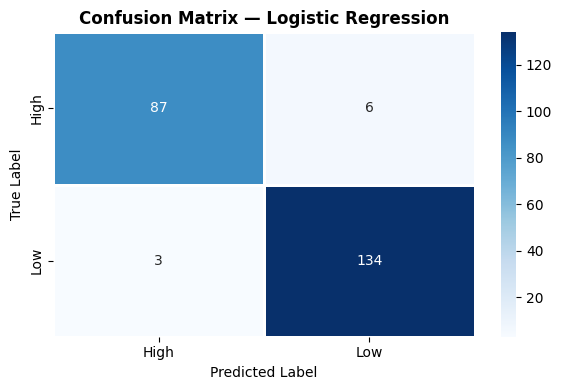

  True High detected (correctly)           : 87
  False Negative (High Risk missed)        : 6  ← Clinically DANGEROUS!
  False Negative Rate (High Risk)          : 0.0645 (6.45%)
  [Note] Low Risk misclassified as High    : 3  (false alarm, not dangerous)
  AUC Score                                : 0.9976
  Accuracy                                 : 0.9609
  10-Fold CV: 0.9651 ± 0.0216


In [22]:

# Logistic Regression

lr = LogisticRegression(max_iter=1000, random_state=SEED)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_val_scaled)
y_prob_lr = lr.predict_proba(X_val_scaled)[:, 1]
acc_lr, auc_lr, fn_lr = evaluate_model(
    'Logistic Regression', y_val, y_pred_lr, y_prob_lr, target_names, 'lr'
)
results['Logistic Regression']     = acc_lr
results_auc['Logistic Regression'] = auc_lr
results_fn['Logistic Regression']  = fn_lr

cv_lr = cross_val_score(lr, X_train_scaled, y_train, cv=kf, scoring='accuracy')
print(f"  10-Fold CV: {cv_lr.mean():.4f} ± {cv_lr.std():.4f}")


  MODEL: Random Forest

Classification Report:
              precision    recall  f1-score   support

        High       0.98      0.98      0.98        93
         Low       0.99      0.99      0.99       137

    accuracy                           0.98       230
   macro avg       0.98      0.98      0.98       230
weighted avg       0.98      0.98      0.98       230



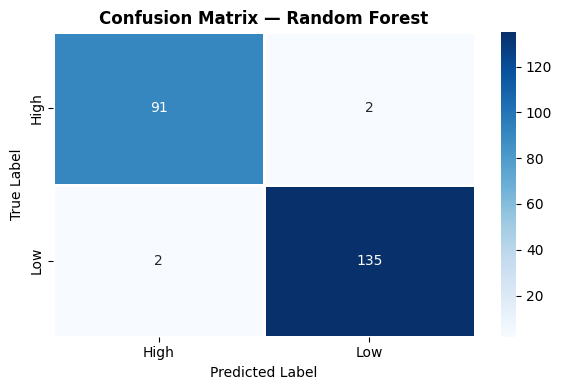

  True High detected (correctly)           : 91
  False Negative (High Risk missed)        : 2  ← Clinically DANGEROUS!
  False Negative Rate (High Risk)          : 0.0215 (2.15%)
  [Note] Low Risk misclassified as High    : 2  (false alarm, not dangerous)
  AUC Score                                : 0.9985
  Accuracy                                 : 0.9826
  10-Fold CV: 0.9815 ± 0.0201


In [23]:

# Random Forest

rf = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_val_scaled)
y_prob_rf = rf.predict_proba(X_val_scaled)[:, 1]
acc_rf, auc_rf, fn_rf = evaluate_model(
    'Random Forest', y_val, y_pred_rf, y_prob_rf, target_names, 'rf'
)
results['Random Forest']     = acc_rf
results_auc['Random Forest'] = auc_rf
results_fn['Random Forest']  = fn_rf

cv_rf = cross_val_score(rf, X_train_scaled, y_train, cv=kf, scoring='accuracy')
print(f"  10-Fold CV: {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")

## 8. MLP - Adam Optimizer

### 8.1 Adam - Without Early Stopping

In [24]:
tf.random.set_seed(SEED)
adam_no_es_opt = tf.keras.optimizers.Adam(learning_rate=0.001)
model_adam_no_es = build_mlp(adam_no_es_opt, X_train_scaled.shape[1])
model_adam_no_es.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,938 (46.63 KB)

 Trainable params: 11,938 (46.63 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history_adam_no_es = model_adam_no_es.fit(
    X_train_smote, y_train_smote,
    epochs=50, batch_size=16,
    validation_data=(X_val_scaled, y_val),
    verbose=1
)
print(f"\nFinal Train Accuracy : {history_adam_no_es.history['accuracy'][-1]:.4f}")
print(f"Final Val Accuracy   : {history_adam_no_es.history['val_accuracy'][-1]:.4f}")

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8431 - loss: 1.2418 - val_accuracy: 0.9652 - val_loss: 0.8292
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9589 - loss: 0.7421 - val_accuracy: 0.9696 - val_loss: 0.5662
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9681 - loss: 0.5150 - val_accuracy: 0.9739 - val_loss: 0.4118
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9690 - loss: 0.3909 - val_accuracy: 0.9696 - val_loss: 0.3182
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9781 - loss: 0.2985 - val_accuracy: 0.9739 - val_loss: 0.2560
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9717 - loss: 0.2592 - val_accuracy: 0.9696 - val_loss: 0.2143
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9763 - loss: 0.2152 - val_accuracy: 0.9696 - val_loss: 0.1859
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9708 - loss: 0.1889 - val_accuracy: 0.9739 - val_loss:

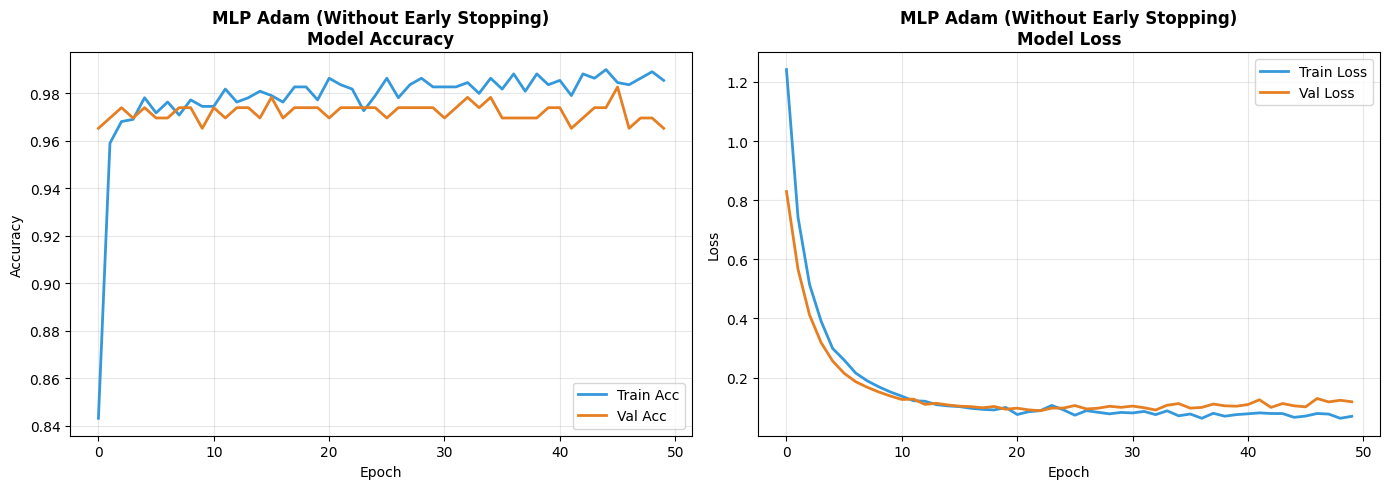

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

  MODEL: MLP Adam (Without ES)

Classification Report:
              precision    recall  f1-score   support

        High       0.95      0.97      0.96        93
         Low       0.98      0.96      0.97       137

    accuracy                           0.97       230
   macro avg       0.96      0.97      0.96       230
weighted avg       0.97      0.97      0.97       230



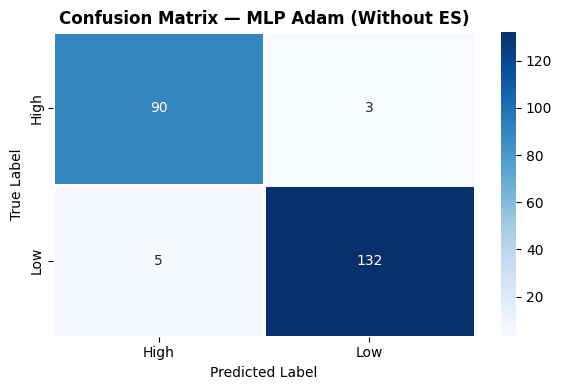

  True High detected (correctly)           : 90
  False Negative (High Risk missed)        : 3  ← Clinically DANGEROUS!
  False Negative Rate (High Risk)          : 0.0323 (3.23%)
  [Note] Low Risk misclassified as High    : 5  (false alarm, not dangerous)
  AUC Score                                : 0.9958
  Accuracy                                 : 0.9652
Training history saved: training_history_adam_without_early_stopping.txt


In [26]:
plot_history(history_adam_no_es, 'MLP Adam (Without Early Stopping)', 'adam_no_es')
acc_adam_no_es, auc_adam_no_es, fn_adam_no_es = evaluate_mlp(
    model_adam_no_es, X_val_scaled, y_val, target_names,
    'MLP Adam (Without ES)', 'adam_no_es'
)
results['MLP Adam (Without ES)']     = acc_adam_no_es
results_auc['MLP Adam (Without ES)'] = auc_adam_no_es
results_fn['MLP Adam (Without ES)']  = fn_adam_no_es

model_adam_no_es.save('model_adam_without_early_stopping.keras')
save_history(history_adam_no_es, 'training_history_adam_without_early_stopping.txt')

### 8.2 Adam — With Early Stopping

In [27]:
tf.random.set_seed(SEED)
adam_es_opt = tf.keras.optimizers.Adam(learning_rate=0.001)
model_adam_es = build_mlp(adam_es_opt, X_train_scaled.shape[1])

early_stop_adam = EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True, verbose=1
)

history_adam_es = model_adam_es.fit(
    X_train_smote, y_train_smote,
    epochs=50, batch_size=16,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stop_adam],
    verbose=1
)
print(f"\nStopped at epoch     : {len(history_adam_es.history['accuracy'])}")
print(f"Final Train Accuracy : {history_adam_es.history['accuracy'][-1]:.4f}")
print(f"Final Val Accuracy   : {history_adam_es.history['val_accuracy'][-1]:.4f}")

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8230 - loss: 1.2976 - val_accuracy: 0.9739 - val_loss: 0.8398
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9599 - loss: 0.7051 - val_accuracy: 0.9652 - val_loss: 0.5385
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9672 - loss: 0.4869 - val_accuracy: 0.9739 - val_loss: 0.3877
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9672 - loss: 0.3651 - val_accuracy: 0.9739 - val_loss: 0.2952
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9717 - loss: 0.2950 - val_accuracy: 0.9696 - val_loss: 0.2367
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9735 - loss: 0.2283 - val_accuracy: 0.9739 - val_loss: 0.1995
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9790 - loss: 0.1921 - val_accuracy: 0.9739 - val_loss: 0.1691
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9808 - loss: 0.1696 - val_accuracy: 0.9739 - val_loss:

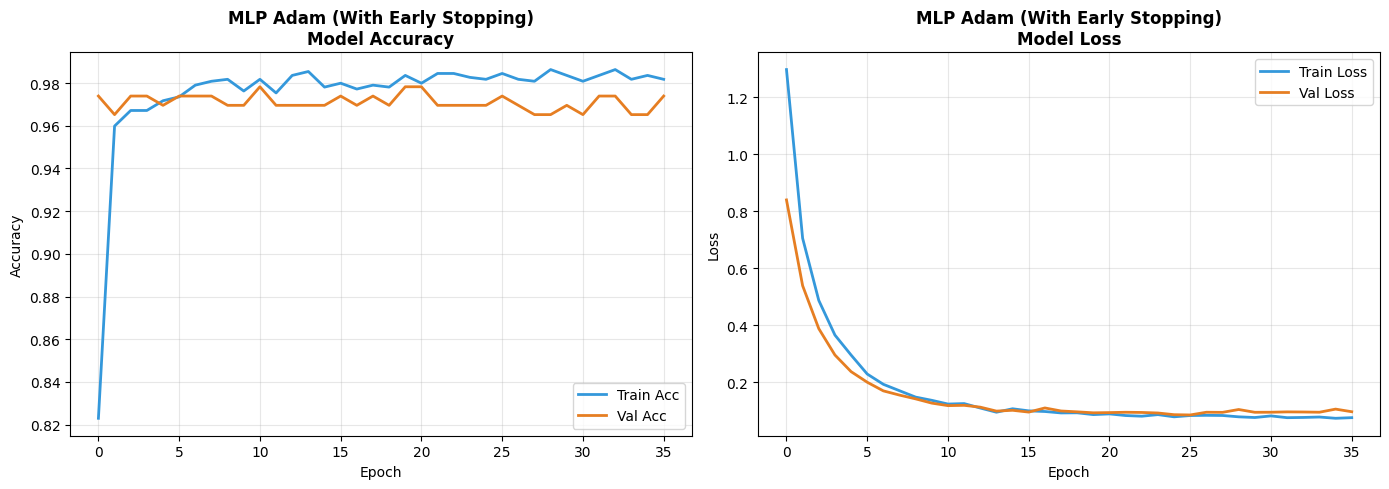

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

  MODEL: MLP Adam (With ES)

Classification Report:
              precision    recall  f1-score   support

        High       0.98      0.96      0.97        93
         Low       0.97      0.99      0.98       137

    accuracy                           0.97       230
   macro avg       0.97      0.97      0.97       230
weighted avg       0.97      0.97      0.97       230



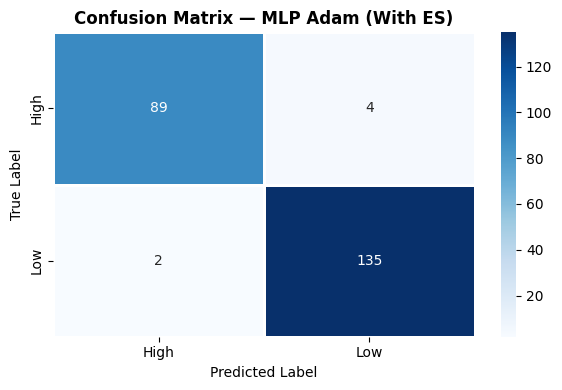

  True High detected (correctly)           : 89
  False Negative (High Risk missed)        : 4  ← Clinically DANGEROUS!
  False Negative Rate (High Risk)          : 0.0430 (4.30%)
  [Note] Low Risk misclassified as High    : 2  (false alarm, not dangerous)
  AUC Score                                : 0.9987
  Accuracy                                 : 0.9739
Training history saved: training_history_adam_with_early_stopping.txt


In [28]:
plot_history(history_adam_es, 'MLP Adam (With Early Stopping)', 'adam_es')
acc_adam_es, auc_adam_es, fn_adam_es = evaluate_mlp(
    model_adam_es, X_val_scaled, y_val, target_names,
    'MLP Adam (With ES)', 'adam_es'
)
results['MLP Adam (With ES)']     = acc_adam_es
results_auc['MLP Adam (With ES)'] = auc_adam_es
results_fn['MLP Adam (With ES)']  = fn_adam_es

model_adam_es.save('model_adam_with_early_stopping.keras')
save_history(history_adam_es, 'training_history_adam_with_early_stopping.txt')

### 8.3 Adam Comparison: With vs Without Early Stopping

In [29]:
comparison_adam = pd.DataFrame({
    'Method': ['Without Early Stopping', 'With Early Stopping'],
    'Final Val Acc': [
        round(history_adam_no_es.history['val_accuracy'][-1], 6),
        round(history_adam_es.history['val_accuracy'][-1], 6)
    ],
    'Final Val Loss': [
        round(history_adam_no_es.history['val_loss'][-1], 6),
        round(history_adam_es.history['val_loss'][-1], 6)
    ],
    'Total Epochs': [
        len(history_adam_no_es.history['accuracy']),
        len(history_adam_es.history['accuracy'])
    ]
})
print("Results Comparison for Adam Optimizer")
print("-" * 65)
print(comparison_adam.to_string(index=False))
print("-" * 65)
comparison_adam.to_csv('comparison_adam.csv', index=False)

Results Comparison for Adam Optimizer
-----------------------------------------------------------------
                Method  Final Val Acc  Final Val Loss  Total Epochs
Without Early Stopping       0.965217        0.118048            50
   With Early Stopping       0.973913        0.095886            36
-----------------------------------------------------------------


---
## 9. MLP — Adamax Optimizer

### 9.1 Adamax — Without Early Stopping

In [30]:
tf.random.set_seed(SEED)
adamax_no_es_opt = tf.keras.optimizers.Adamax(learning_rate=0.005)
model_adamax_no_es = build_mlp(adamax_no_es_opt, X_train_scaled.shape[1])
model_adamax_no_es.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,938 (46.63 KB)

 Trainable params: 11,938 (46.63 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history_adamax_no_es = model_adamax_no_es.fit(
    X_train_smote, y_train_smote,
    epochs=50, batch_size=16,
    validation_data=(X_val_scaled, y_val),
    verbose=1
)
print(f"\nFinal Train Accuracy : {history_adamax_no_es.history['accuracy'][-1]:.4f}")
print(f"Final Val Accuracy   : {history_adamax_no_es.history['val_accuracy'][-1]:.4f}")

Epoch 1/50


69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9133 - loss: 0.8944 - val_accuracy: 0.9652 - val_loss: 0.5425
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9644 - loss: 0.4955 - val_accuracy: 0.9696 - val_loss: 0.3802
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9699 - loss: 0.3709 - val_accuracy: 0.9739 - val_loss: 0.2959
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9754 - loss: 0.2994 - val_accuracy: 0.9696 - val_loss: 0.2495
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9644 - loss: 0.2502 - val_accuracy: 0.9652 - val_loss: 0.2162
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9708 - loss: 0.2234 - val_accuracy: 0.9696 - val_loss: 0.1893
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9690 - loss: 0.1949 - val_accuracy: 0.9652 - val_loss: 0.1707
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9726 - loss: 0.1730 - val_accuracy: 0.9696 - val_loss: 0.1554
Epo

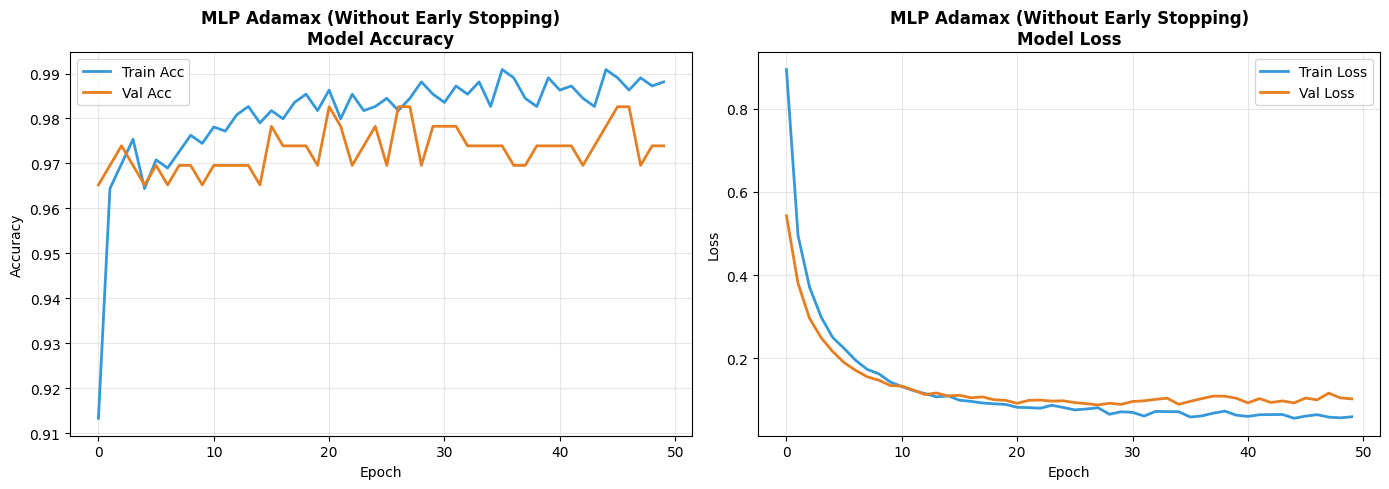

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

  MODEL: MLP Adamax (Without ES)

Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.97      0.97        93
         Low       0.98      0.98      0.98       137

    accuracy                           0.97       230
   macro avg       0.97      0.97      0.97       230
weighted avg       0.97      0.97      0.97       230



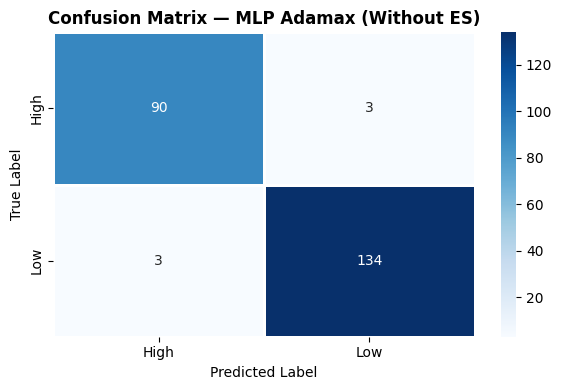

  True High detected (correctly)           : 90
  False Negative (High Risk missed)        : 3  ← Clinically DANGEROUS!
  False Negative Rate (High Risk)          : 0.0323 (3.23%)
  [Note] Low Risk misclassified as High    : 3  (false alarm, not dangerous)
  AUC Score                                : 0.9966
  Accuracy                                 : 0.9739
Training history saved: training_history_adamax_without_early_stopping.txt


In [32]:
plot_history(history_adamax_no_es, 'MLP Adamax (Without Early Stopping)', 'adamax_no_es')
acc_adamax_no_es, auc_adamax_no_es, fn_adamax_no_es = evaluate_mlp(
    model_adamax_no_es, X_val_scaled, y_val, target_names,
    'MLP Adamax (Without ES)', 'adamax_no_es'
)
results['MLP Adamax (Without ES)']     = acc_adamax_no_es
results_auc['MLP Adamax (Without ES)'] = auc_adamax_no_es
results_fn['MLP Adamax (Without ES)']  = fn_adamax_no_es

model_adamax_no_es.save('model_adamax_without_early_stopping.keras')
save_history(history_adamax_no_es, 'training_history_adamax_without_early_stopping.txt')

### 9.2 Adamax — With Early Stopping

In [33]:
tf.random.set_seed(SEED)
adamax_es_opt = tf.keras.optimizers.Adamax(learning_rate=0.005)
model_adamax_es = build_mlp(adamax_es_opt, X_train_scaled.shape[1])

early_stop_adamax = EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True, verbose=1
)

history_adamax_es = model_adamax_es.fit(
    X_train_smote, y_train_smote,
    epochs=50, batch_size=16,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stop_adamax],
    verbose=1
)
print(f"\nStopped at epoch     : {len(history_adamax_es.history['accuracy'])}")
print(f"Final Train Accuracy : {history_adamax_es.history['accuracy'][-1]:.4f}")
print(f"Final Val Accuracy   : {history_adamax_es.history['val_accuracy'][-1]:.4f}")

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9133 - loss: 0.9758 - val_accuracy: 0.9696 - val_loss: 0.6579
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9644 - loss: 0.5847 - val_accuracy: 0.9696 - val_loss: 0.4817
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9644 - loss: 0.4696 - val_accuracy: 0.9739 - val_loss: 0.3895
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9690 - loss: 0.3828 - val_accuracy: 0.9696 - val_loss: 0.3267
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9735 - loss: 0.3294 - val_accuracy: 0.9696 - val_loss: 0.2840
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9781 - loss: 0.2746 - val_accuracy: 0.9739 - val_loss: 0.2475
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9799 - loss: 0.2423 - val_accuracy: 0.9739 - val_loss: 0.2195
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9754 - loss: 0.2214 - val_accuracy: 0.9652 - val_loss:

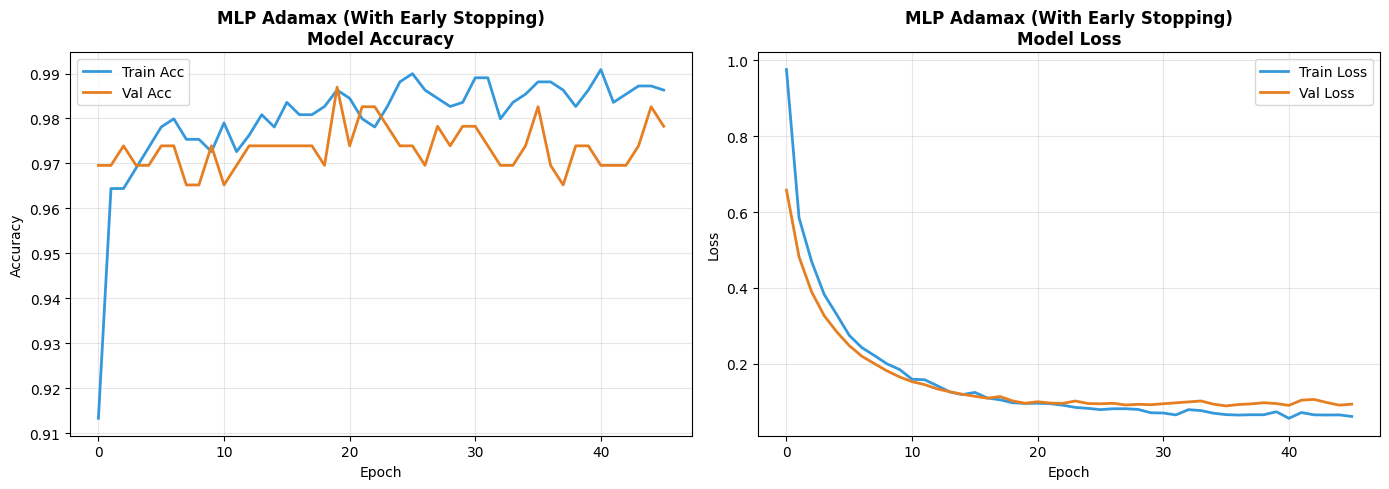

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

  MODEL: MLP Adamax (With ES)

Classification Report:
              precision    recall  f1-score   support

        High       0.99      0.97      0.98        93
         Low       0.98      0.99      0.99       137

    accuracy                           0.98       230
   macro avg       0.98      0.98      0.98       230
weighted avg       0.98      0.98      0.98       230



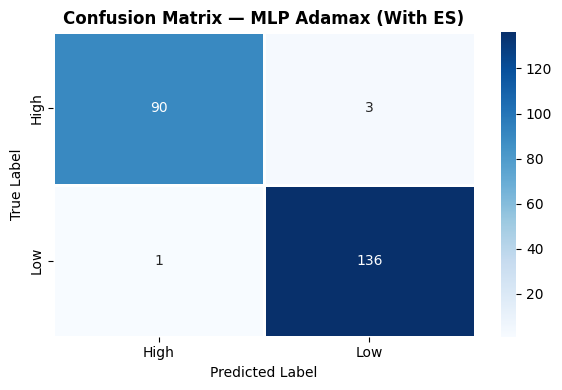

  True High detected (correctly)           : 90
  False Negative (High Risk missed)        : 3  ← Clinically DANGEROUS!
  False Negative Rate (High Risk)          : 0.0323 (3.23%)
  [Note] Low Risk misclassified as High    : 1  (false alarm, not dangerous)
  AUC Score                                : 0.9982
  Accuracy                                 : 0.9826
Training history saved: training_history_adamax_with_early_stopping.txt


In [34]:
plot_history(history_adamax_es, 'MLP Adamax (With Early Stopping)', 'adamax_es')
acc_adamax_es, auc_adamax_es, fn_adamax_es = evaluate_mlp(
    model_adamax_es, X_val_scaled, y_val, target_names,
    'MLP Adamax (With ES)', 'adamax_es'
)
results['MLP Adamax (With ES)']     = acc_adamax_es
results_auc['MLP Adamax (With ES)'] = auc_adamax_es
results_fn['MLP Adamax (With ES)']  = fn_adamax_es

model_adamax_es.save('model_adamax_with_early_stopping.keras')
save_history(history_adamax_es, 'training_history_adamax_with_early_stopping.txt')

### 9.3 Adamax Comparison: With vs Without Early Stopping

In [35]:
comparison_adamax = pd.DataFrame({
    'Method': ['Without Early Stopping', 'With Early Stopping'],
    'Final Val Acc': [
        round(history_adamax_no_es.history['val_accuracy'][-1], 6),
        round(history_adamax_es.history['val_accuracy'][-1], 6)
    ],
    'Final Val Loss': [
        round(history_adamax_no_es.history['val_loss'][-1], 6),
        round(history_adamax_es.history['val_loss'][-1], 6)
    ],
    'Total Epochs': [
        len(history_adamax_no_es.history['accuracy']),
        len(history_adamax_es.history['accuracy'])
    ]
})
print("Results Comparison for Adamax Optimizer")
print("-" * 65)
print(comparison_adamax.to_string(index=False))
print("-" * 65)
comparison_adamax.to_csv('comparison_adamax.csv', index=False)

Results Comparison for Adamax Optimizer
-----------------------------------------------------------------
                Method  Final Val Acc  Final Val Loss  Total Epochs
Without Early Stopping       0.973913        0.102244            50
   With Early Stopping       0.978261        0.093115            46
-----------------------------------------------------------------


---
## 10. ROC-AUC Analysis

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


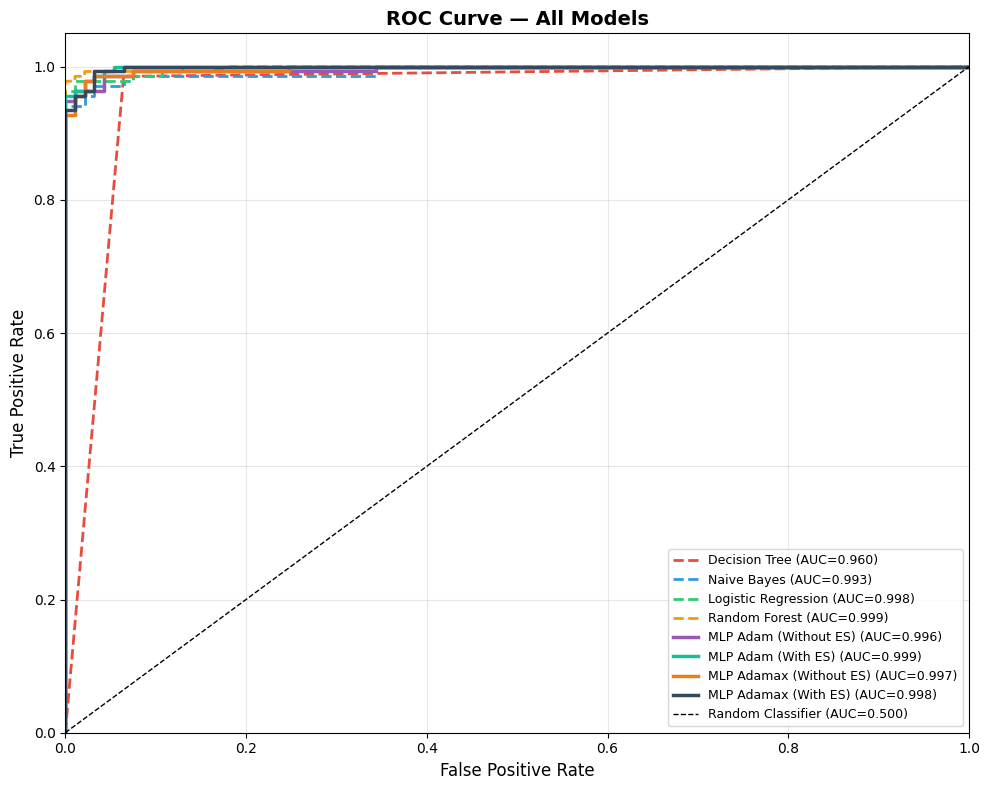


AUC Score — All Models:
------------------------------------------
                  Model      AUC
     MLP Adam (With ES) 0.998666
          Random Forest 0.998509
   MLP Adamax (With ES) 0.998195
    Logistic Regression 0.997567
MLP Adamax (Without ES) 0.996625
  MLP Adam (Without ES) 0.995840
            Naive Bayes 0.993172
          Decision Tree 0.960443


In [36]:
# ============================================================
# ROC CURVE — All Models
# ============================================================
plt.figure(figsize=(10, 8))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12',
          '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

baseline_models = [
    ('Decision Tree',       y_prob_dt),
    ('Naive Bayes',         y_prob_nb),
    ('Logistic Regression', y_prob_lr),
    ('Random Forest',       y_prob_rf),
]

mlp_models = [
    ('MLP Adam (Without ES)',  model_adam_no_es),
    ('MLP Adam (With ES)',     model_adam_es),
    ('MLP Adamax (Without ES)',model_adamax_no_es),
    ('MLP Adamax (With ES)',   model_adamax_es),
]

all_roc_data = []

for i, (name, y_prob) in enumerate(baseline_models):
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc_score = roc_auc_score(y_val, y_prob)
    plt.plot(fpr, tpr, color=colors[i], linewidth=2,
             label=f'{name} (AUC={auc_score:.3f})', linestyle='--')
    all_roc_data.append({'Model': name, 'AUC': auc_score})

for i, (name, model) in enumerate(mlp_models):
    y_prob = model.predict(X_val_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc_score = roc_auc_score(y_val, y_prob)
    plt.plot(fpr, tpr, color=colors[i+4], linewidth=2.5,
             label=f'{name} (AUC={auc_score:.3f})')
    all_roc_data.append({'Model': name, 'AUC': auc_score})

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier (AUC=0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

roc_df = pd.DataFrame(all_roc_data).sort_values('AUC', ascending=False)
print("\nAUC Score — All Models:")
print("-" * 42)
print(roc_df.to_string(index=False))
roc_df.to_csv('auc_scores.csv', index=False)

---
## 11. 10-Fold Cross Validation — Best MLP (Adam + Early Stopping) & Best MLP (Adamax + Early Stopping)

In [37]:
print("Running 10-Fold Cross Validation for MLP Adam + Early Stopping...")
print("This may take several minutes...\n")

kf10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
cv_accuracies = []
cv_aucs       = []

X_full_scaled = scaler.fit_transform(X)
y_full        = np.array(y)

for fold, (train_idx, val_idx) in enumerate(kf10.split(X_full_scaled, y_full)):
    X_tr, X_v = X_full_scaled[train_idx], X_full_scaled[val_idx]
    y_tr, y_v = y_full[train_idx], y_full[val_idx]

    # SMOTE per fold
    smote_fold = SMOTE(random_state=SEED)
    X_tr_sm, y_tr_sm = smote_fold.fit_resample(X_tr, y_tr)

    # Build model
    tf.random.set_seed(SEED)
    opt_fold   = tf.keras.optimizers.Adam(learning_rate=0.001)
    model_fold = build_mlp(opt_fold, X_tr_sm.shape[1])

    es_fold = EarlyStopping(monitor='val_loss', patience=10,
                            restore_best_weights=True, verbose=0)

    model_fold.fit(
        X_tr_sm, y_tr_sm,
        epochs=50, batch_size=16,
        validation_data=(X_v, y_v),
        callbacks=[es_fold],
        verbose=0
    )

    y_prob_fold = model_fold.predict(X_v, verbose=0)[:, 1]
    y_pred_fold = np.argmax(model_fold.predict(X_v, verbose=0), axis=1)

    acc      = accuracy_score(y_v, y_pred_fold)
    auc_fold = roc_auc_score(y_v, y_prob_fold)

    cv_accuracies.append(acc)
    cv_aucs.append(auc_fold)
    print(f"  Fold {fold+1:2d}: Accuracy = {acc:.4f} | AUC = {auc_fold:.4f}")

print(f"\n{'='*55}")
print(f"  10-Fold CV — MLP Adam + Early Stopping")
print(f"{'='*55}")
print(f"  Mean Accuracy : {np.mean(cv_accuracies):.4f}")
print(f"  Std Accuracy  : {np.std(cv_accuracies):.4f}")
print(f"  Min Accuracy  : {np.min(cv_accuracies):.4f}")
print(f"  Max Accuracy  : {np.max(cv_accuracies):.4f}")
print(f"  Mean AUC      : {np.mean(cv_aucs):.4f}")
print(f"  Std AUC       : {np.std(cv_aucs):.4f}")
print(f"{'='*55}")

Running 10-Fold Cross Validation for MLP Adam + Early Stopping...
This may take several minutes...

  Fold  1: Accuracy = 0.9826 | AUC = 0.9991
  Fold  2: Accuracy = 0.9565 | AUC = 0.9947
  Fold  3: Accuracy = 0.9913 | AUC = 0.9997
  Fold  4: Accuracy = 0.9652 | AUC = 0.9968
  Fold  5: Accuracy = 0.9652 | AUC = 0.9953
  Fold  6: Accuracy = 0.9652 | AUC = 0.9943
  Fold  7: Accuracy = 0.9913 | AUC = 0.9991
  Fold  8: Accuracy = 0.9652 | AUC = 0.9981
  Fold  9: Accuracy = 0.9912 | AUC = 1.0000
  Fold 10: Accuracy = 0.9912 | AUC = 0.9997

  10-Fold CV — MLP Adam + Early Stopping
  Mean Accuracy : 0.9765
  Std Accuracy  : 0.0135
  Min Accuracy  : 0.9565
  Max Accuracy  : 0.9913
  Mean AUC      : 0.9977
  Std AUC       : 0.0021


### 11.2 10-Fold Cross Validation — Best MLP (Adamax + Early Stopping)


In [38]:
print("Running 10-Fold Cross Validation for MLP Adamax + Early Stopping (Best MLP)...")
print("This may take several minutes...\n")

kf10_adamax = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
cv_accuracies_adamax = []
cv_aucs_adamax       = []

X_full_scaled_adamax = scaler.fit_transform(X)
y_full_adamax        = np.array(y)

for fold, (train_idx, val_idx) in enumerate(kf10_adamax.split(X_full_scaled_adamax, y_full_adamax)):
    X_tr, X_v = X_full_scaled_adamax[train_idx], X_full_scaled_adamax[val_idx]
    y_tr, y_v = y_full_adamax[train_idx], y_full_adamax[val_idx]

    # SMOTE per fold
    smote_fold = SMOTE(random_state=SEED)
    X_tr_sm, y_tr_sm = smote_fold.fit_resample(X_tr, y_tr)

    # Build model with Adamax optimizer
    tf.random.set_seed(SEED)
    opt_fold   = tf.keras.optimizers.Adamax(learning_rate=0.005)
    model_fold = build_mlp(opt_fold, X_tr_sm.shape[1])

    es_fold = EarlyStopping(monitor='val_loss', patience=10,
                            restore_best_weights=True, verbose=0)

    model_fold.fit(
        X_tr_sm, y_tr_sm,
        epochs=50, batch_size=16,
        validation_data=(X_v, y_v),
        callbacks=[es_fold],
        verbose=0
    )

    y_prob_fold = model_fold.predict(X_v, verbose=0)[:, 1]
    y_pred_fold = np.argmax(model_fold.predict(X_v, verbose=0), axis=1)

    acc      = accuracy_score(y_v, y_pred_fold)
    auc_fold = roc_auc_score(y_v, y_prob_fold)

    cv_accuracies_adamax.append(acc)
    cv_aucs_adamax.append(auc_fold)
    print(f"  Fold {fold+1:2d}: Accuracy = {acc:.4f} | AUC = {auc_fold:.4f}")

print(f"\n{'='*55}")
print(f"  10-Fold CV — MLP Adamax + Early Stopping (Best MLP)")
print(f"{'='*55}")
print(f"  Mean Accuracy : {np.mean(cv_accuracies_adamax):.4f}")
print(f"  Std Accuracy  : {np.std(cv_accuracies_adamax):.4f}")
print(f"  Min Accuracy  : {np.min(cv_accuracies_adamax):.4f}")
print(f"  Max Accuracy  : {np.max(cv_accuracies_adamax):.4f}")
print(f"  Mean AUC      : {np.mean(cv_aucs_adamax):.4f}")
print(f"  Std AUC       : {np.std(cv_aucs_adamax):.4f}")
print(f"{'='*55}")

# Save CV results
cv_adamax_df = pd.DataFrame({
    'Fold'    : list(range(1, 11)),
    'Accuracy': [round(a, 4) for a in cv_accuracies_adamax],
    'AUC'     : [round(a, 4) for a in cv_aucs_adamax]
})
cv_adamax_df.to_csv('cv_results_adamax_es.csv', index=False)
print("\nCV results saved: cv_results_adamax_es.csv")

Running 10-Fold Cross Validation for MLP Adamax + Early Stopping (Best MLP)...
This may take several minutes...

  Fold  1: Accuracy = 0.9826 | AUC = 0.9987
  Fold  2: Accuracy = 0.9565 | AUC = 0.9962
  Fold  3: Accuracy = 0.9826 | AUC = 0.9994
  Fold  4: Accuracy = 0.9652 | AUC = 0.9972
  Fold  5: Accuracy = 0.9739 | AUC = 0.9950
  Fold  6: Accuracy = 0.9652 | AUC = 0.9931
  Fold  7: Accuracy = 0.9913 | AUC = 0.9987
  Fold  8: Accuracy = 0.9652 | AUC = 0.9987
  Fold  9: Accuracy = 0.9912 | AUC = 1.0000
  Fold 10: Accuracy = 0.9912 | AUC = 1.0000

  10-Fold CV — MLP Adamax + Early Stopping (Best MLP)
  Mean Accuracy : 0.9765
  Std Accuracy  : 0.0123
  Min Accuracy  : 0.9565
  Max Accuracy  : 0.9913
  Mean AUC      : 0.9977
  Std AUC       : 0.0022

CV results saved: cv_results_adamax_es.csv


---
## 12. SHAP Feature Importance Analysis

Computing SHAP values...


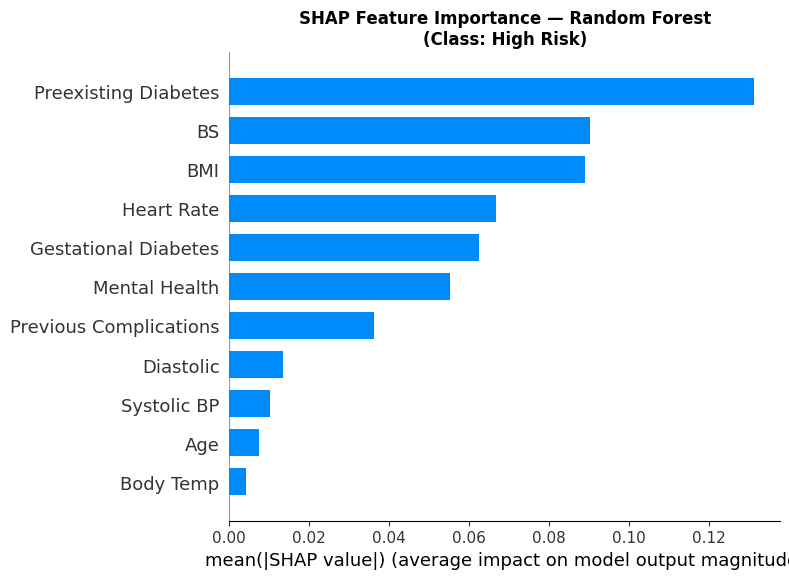

In [39]:
# ============================================================
# SHAP using Random Forest (more stable for SHAP TreeExplainer)
# ============================================================
print("Computing SHAP values...")

explainer  = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_val_scaled)

feature_names = X.columns.tolist()

# SHAP Summary Plot — Bar (Feature Importance)
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values[:, :, 1],
    X_val_scaled,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance — Random Forest\n(Class: High Risk)',
          fontweight='bold')
plt.tight_layout()
plt.savefig('shap_feature_importance_bar.png', dpi=300, bbox_inches='tight')
plt.show()

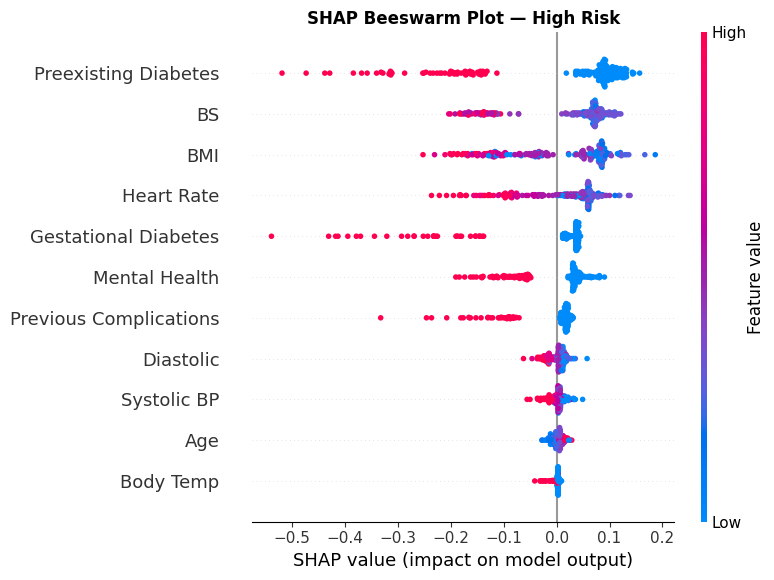


Most influential features (High Risk):
--------------------------------------------------
               Feature  SHAP Importance (Mean |SHAP|)
  Preexisting Diabetes                       0.131304
                    BS                       0.090233
                   BMI                       0.089168
            Heart Rate                       0.066731
  Gestational Diabetes                       0.062513
         Mental Health                       0.055221
Previous Complications                       0.036096
             Diastolic                       0.013502
           Systolic BP                       0.010143
                   Age                       0.007398
             Body Temp                       0.004158


In [40]:
# SHAP Beeswarm Plot (value magnitude and direction of impact)
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values[:, :, 1],
    X_val_scaled,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Beeswarm Plot — High Risk', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

# SHAP importance table
shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'SHAP Importance (Mean |SHAP|)': np.abs(shap_values[:, :, 1]).mean(axis=0)
}).sort_values('SHAP Importance (Mean |SHAP|)', ascending=False)

print("\nMost influential features (High Risk):")
print("-" * 50)
print(shap_importance.to_string(index=False))
shap_importance.to_csv('shap_feature_importance.csv', index=False)

---
## 13. False Negative (Clinical Impact) Analysis

FALSE NEGATIVE ANALYSIS — High Risk Cases Missed (Clinically Dangerous)
Total High Risk patients in validation set: 93
                  Model  False Negative (High Risk Missed)  FN Rate (%)  Accuracy      AUC
          Random Forest                                  2         2.15  0.982609 0.998509
   MLP Adamax (With ES)                                  3         3.23  0.982609 0.998195
MLP Adamax (Without ES)                                  3         3.23  0.973913 0.996625
  MLP Adam (Without ES)                                  3         3.23  0.965217 0.995840
     MLP Adam (With ES)                                  4         4.30  0.973913 0.998666
          Decision Tree                                  6         6.45  0.965217 0.960443
    Logistic Regression                                  6         6.45  0.960870 0.997567
            Naive Bayes                                 10        10.75  0.947826 0.993172


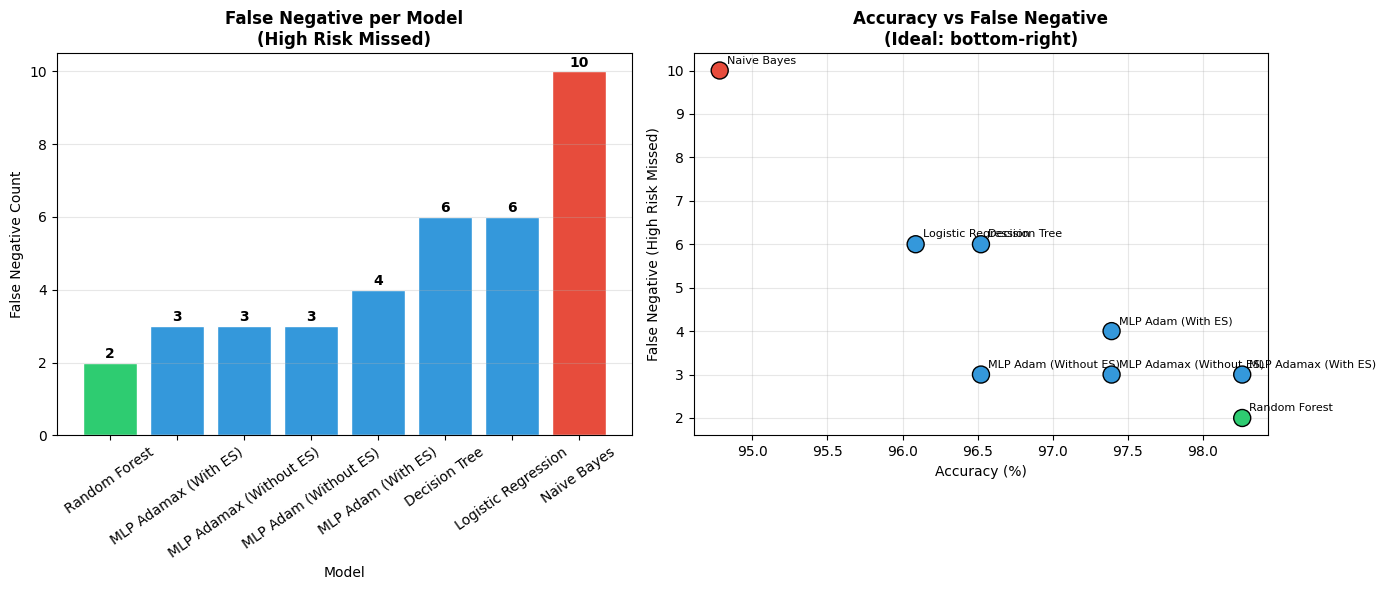

In [41]:
# ============================================================
# FALSE NEGATIVE ANALYSIS
# False Negative = High Risk patient NOT detected by the model
# This is clinically dangerous — undetected high-risk pregnancies
# can lead to severe complications or maternal mortality.
# ============================================================

fn_data = pd.DataFrame({
    'Model': list(results_fn.keys()),
    'False Negative (High Risk Missed)': list(results_fn.values()),
    'Accuracy': [results[m] for m in results_fn.keys()],
    'AUC': [results_auc[m] for m in results_fn.keys()]
})
fn_data = fn_data.sort_values('False Negative (High Risk Missed)')
fn_data['FN Rate (%)'] = (fn_data['False Negative (High Risk Missed)'] / 93 * 100).round(2)

print("=" * 72)
print("FALSE NEGATIVE ANALYSIS — High Risk Cases Missed (Clinically Dangerous)")
print("Total High Risk patients in validation set: 93")
print("=" * 72)
print(fn_data[['Model', 'False Negative (High Risk Missed)',
               'FN Rate (%)', 'Accuracy', 'AUC']].to_string(index=False))

fn_data.to_csv('false_negative_analysis.csv', index=False)

# Visualize False Negative
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def get_bar_colors(values, reverse=False):
    colors = []
    for v in values:
        if (not reverse and v == max(values)) or (reverse and v == min(values)):
            colors.append('#e74c3c')
        elif (not reverse and v == min(values)) or (reverse and v == max(values)):
            colors.append('#2ecc71')
        else:
            colors.append('#3498db')
    return colors

fn_vals = fn_data['False Negative (High Risk Missed)'].tolist()
colors_fn = get_bar_colors(fn_vals)

bars = axes[0].bar(fn_data['Model'], fn_vals,
                   color=colors_fn, edgecolor='white')
for bar, val in zip(bars, fn_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 str(int(val)), ha='center', va='bottom', fontweight='bold')
axes[0].set_title('False Negative per Model\n(High Risk Missed)', fontweight='bold')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('False Negative Count')
axes[0].tick_params(axis='x', rotation=35)
axes[0].grid(axis='y', alpha=0.3)

axes[1].scatter(fn_data['Accuracy'] * 100,
                fn_data['False Negative (High Risk Missed)'],
                s=150, c=colors_fn, edgecolors='black', zorder=5)
for _, row in fn_data.iterrows():
    axes[1].annotate(row['Model'],
                     (row['Accuracy'] * 100,
                      row['False Negative (High Risk Missed)']),
                     textcoords='offset points', xytext=(5, 5), fontsize=8)
axes[1].set_xlabel('Accuracy (%)')
axes[1].set_ylabel('False Negative (High Risk Missed)')
axes[1].set_title('Accuracy vs False Negative\n(Ideal: bottom-right)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('false_negative_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 14. Final Model Comparison

In [42]:
# Comprehensive comparison table — all models
final_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': list(results.values()),
    'AUC': [results_auc[m] for m in results.keys()],
    'False Negative': [results_fn[m] for m in results.keys()]
})
final_df = final_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
final_df['Rank']         = final_df.index + 1
final_df['Accuracy (%)'] = (final_df['Accuracy'] * 100).round(2)
final_df['AUC']          = final_df['AUC'].round(4)

print("=" * 70)
print("FINAL COMPARISON — ALL MODELS")
print("=" * 70)
print(final_df[['Rank', 'Model', 'Accuracy (%)', 'AUC',
                'False Negative']].to_string(index=False))
print("=" * 70)

final_df.to_csv('comparison_all_models.csv', index=False)

FINAL COMPARISON — ALL MODELS
 Rank                   Model  Accuracy (%)    AUC  False Negative
    1           Random Forest         98.26 0.9985               2
    2    MLP Adamax (With ES)         98.26 0.9982               3
    3      MLP Adam (With ES)         97.39 0.9987               4
    4 MLP Adamax (Without ES)         97.39 0.9966               3
    5           Decision Tree         96.52 0.9604               6
    6   MLP Adam (Without ES)         96.52 0.9958               3
    7     Logistic Regression         96.09 0.9976               6
    8             Naive Bayes         94.78 0.9932              10


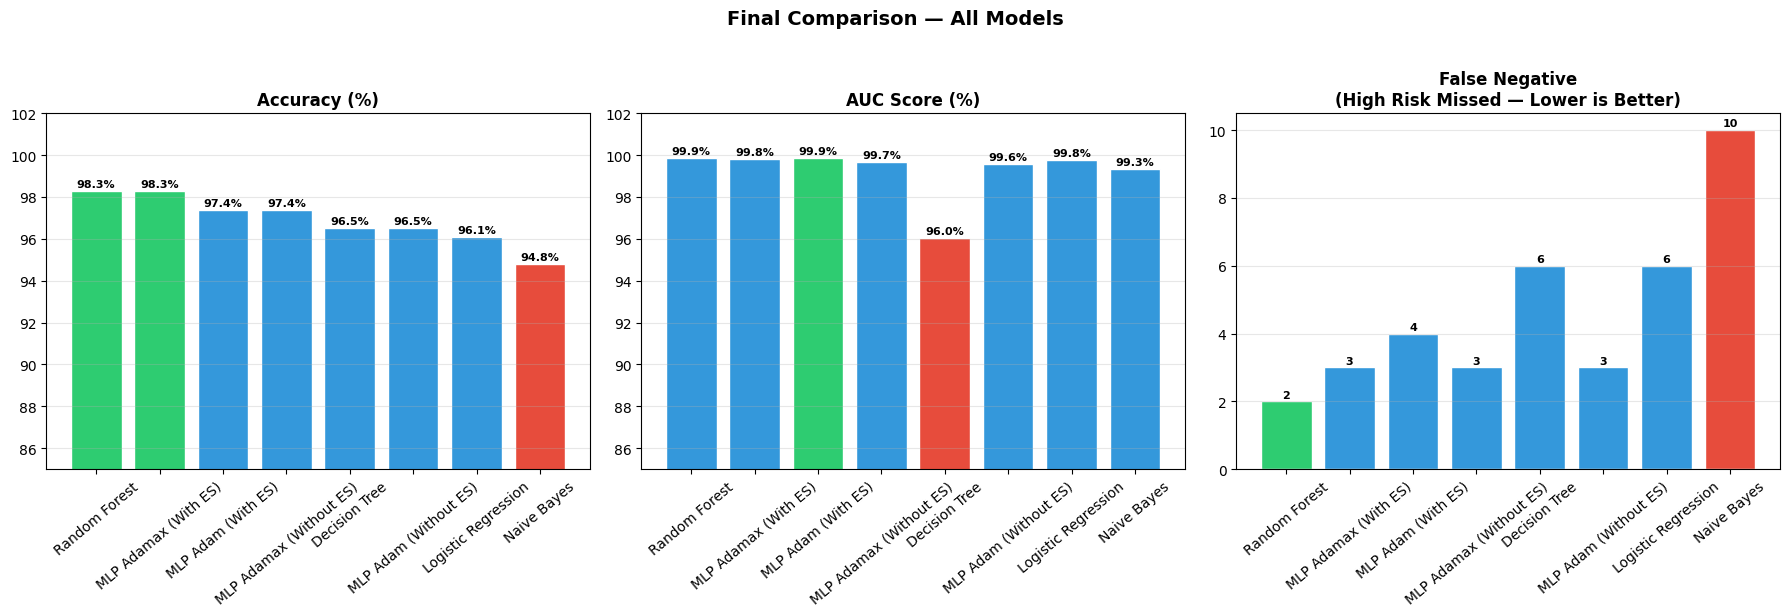

In [43]:
# Visualization — all models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

def get_colors(values, reverse=False):
    out = []
    for v in values:
        if (not reverse and v == max(values)) or (reverse and v == min(values)):
            out.append('#2ecc71')
        elif (not reverse and v == min(values)) or (reverse and v == max(values)):
            out.append('#e74c3c')
        else:
            out.append('#3498db')
    return out

models = final_df['Model'].tolist()
accs   = final_df['Accuracy (%)'].tolist()
aucs   = (final_df['AUC'] * 100).tolist()
fns    = final_df['False Negative'].tolist()

# Plot 1: Accuracy
bars1 = axes[0].bar(models, accs, color=get_colors(accs), edgecolor='white')
for bar, v in zip(bars1, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[0].set_title('Accuracy (%)', fontweight='bold')
axes[0].set_ylim(85, 102)
axes[0].tick_params(axis='x', rotation=40)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: AUC
bars2 = axes[1].bar(models, aucs, color=get_colors(aucs), edgecolor='white')
for bar, v in zip(bars2, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[1].set_title('AUC Score (%)', fontweight='bold')
axes[1].set_ylim(85, 102)
axes[1].tick_params(axis='x', rotation=40)
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: False Negative (lower is better)
bars3 = axes[2].bar(models, fns, color=get_colors(fns, reverse=True), edgecolor='white')
for bar, v in zip(bars3, fns):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 str(int(v)), ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[2].set_title('False Negative\n(High Risk Missed — Lower is Better)',
                   fontweight='bold')
axes[2].tick_params(axis='x', rotation=40)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Final Comparison — All Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparison_all_models_chart.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 15. Final Conclusion

In [44]:
best_overall  = final_df.iloc[0]
best_mlp      = final_df[final_df['Model'].str.contains('MLP')].iloc[0]
safest_model  = final_df.sort_values('False Negative').iloc[0]

print("=" * 65)
print("  FINAL CONCLUSION")
print("=" * 65)
print(f"\n  Task            : Binary Classification (High vs Low Risk)")
print(f"  Total Samples   : {len(X)} (after cleaning)")
print(f"  Training Set    : {X_train_scaled.shape[0]} samples")
print(f"  Validation Set  : {X_val_scaled.shape[0]} samples")
print(f"  Features        : {X.shape[1]}")
print(f"  Classes         : {le.classes_.tolist()}")

print(f"\n  Best model (Accuracy):")
print(f"  → {best_overall['Model']}")
print(f"    Accuracy: {best_overall['Accuracy (%)']:.2f}% | AUC: {best_overall['AUC']:.4f}")

print(f"\n  Best MLP model:")
print(f"  → {best_mlp['Model']}")
print(f"    Accuracy: {best_mlp['Accuracy (%)']:.2f}% | AUC: {best_mlp['AUC']:.4f}")

print(f"\n  Clinically safest model (lowest False Negative):")
print(f"  → {safest_model['Model']}")
print(f"    False Negative: {int(safest_model['False Negative'])} cases")

print(f"\n  10-Fold CV — MLP Adam + Early Stopping:")
print(f"  → Mean Accuracy : {np.mean(cv_accuracies):.4f} ± {np.std(cv_accuracies):.4f}")
print(f"  → Mean AUC      : {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")

print(f"\n  Top 3 most influential features (SHAP):")
for i, row in shap_importance.head(3).iterrows():
    print(f"  → {row['Feature']} (SHAP: {row['SHAP Importance (Mean |SHAP|)']:.4f})")

print(f"\n  Output files generated:")
files = [
    'model_adam_without_early_stopping.keras',
    'model_adam_with_early_stopping.keras',
    'model_adamax_without_early_stopping.keras',
    'model_adamax_with_early_stopping.keras',
    'roc_curve_all_models.png',
    'shap_feature_importance_bar.png',
    'shap_beeswarm.png',
    'false_negative_analysis.png',
    'comparison_all_models.csv',
    'auc_scores.csv',
    'shap_feature_importance.csv',
    'false_negative_analysis.csv'
]
for f in files:
    print(f"  → {f}")
print("=" * 65)

  FINAL CONCLUSION

  Task            : Binary Classification (High vs Low Risk)
  Total Samples   : 1148 (after cleaning)
  Training Set    : 918 samples
  Validation Set  : 230 samples
  Features        : 11
  Classes         : ['High', 'Low']

  Best model (Accuracy):
  → Random Forest
    Accuracy: 98.26% | AUC: 0.9985

  Best MLP model:
  → MLP Adamax (With ES)
    Accuracy: 98.26% | AUC: 0.9982

  Clinically safest model (lowest False Negative):
  → Random Forest
    False Negative: 2 cases

  10-Fold CV — MLP Adam + Early Stopping:
  → Mean Accuracy : 0.9765 ± 0.0135
  → Mean AUC      : 0.9977 ± 0.0021

  Top 3 most influential features (SHAP):
  → Preexisting Diabetes (SHAP: 0.1313)
  → BS (SHAP: 0.0902)
  → BMI (SHAP: 0.0892)

  Output files generated:
  → model_adam_without_early_stopping.keras
  → model_adam_with_early_stopping.keras
  → model_adamax_without_early_stopping.keras
  → model_adamax_with_early_stopping.keras
  → roc_curve_all_models.png
  → shap_feature_importan

**Save Best Model**

In [45]:
# ============================================================
# SAVE BEST MODEL — MLP Adamax + Early Stopping
# ============================================================

import os
import json
from datetime import datetime

print("=" * 60)
print("  SAVING BEST MODEL")
print("=" * 60)

# ── 1. Save Keras model ──────────────────────────────────────
best_model_path = 'best_model_mlp_adamax_es.keras'
model_adamax_es.save(best_model_path)
print(f"\n✓ Model saved       : {best_model_path}")

# ── 2. Save scaler and label encoder ────────────────────────
scaler_path = 'best_model_scaler.pkl'
le_path     = 'best_model_label_encoder.pkl'
joblib.dump(scaler, scaler_path)
joblib.dump(le,     le_path)
print(f"✓ Scaler saved      : {scaler_path}")
print(f"✓ LabelEncoder saved: {le_path}")

# ── 3. Save model metadata (JSON) ───────────────────────────
metadata = {
    "model_name"       : "MLP Adamax with Early Stopping",
    "saved_at"         : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "task"             : "Binary Classification",
    "classes"          : le.classes_.tolist(),
    "num_classes"      : len(le.classes_),
    "num_features"     : X.shape[1],
    "feature_names"    : X.columns.tolist(),
    "total_samples"    : len(X),
    "training_samples" : X_train_scaled.shape[0],
    "validation_samples": X_val_scaled.shape[0],
    "architecture": {
        "layers"       : [128, 64, 32, len(le.classes_)],
        "activations"  : ["relu", "relu", "relu", "softmax"],
        "dropout_rates": [0.5, 0.3, 0.2],
        "regularizer"  : "L2(0.01)"
    },
    "training_config": {
        "optimizer"    : "Adamax",
        "learning_rate": 0.005,
        "loss"         : "sparse_categorical_crossentropy",
        "batch_size"   : 16,
        "max_epochs"   : 50,
        "early_stopping": {
            "monitor"          : "val_loss",
            "patience"         : 10,
            "restore_best_weights": True
        },
        "actual_epochs": len(history_adamax_es.history['accuracy']),
        "smote"        : True,
        "random_seed"  : SEED
    },
    "performance": {
        "accuracy"      : round(acc_adamax_es, 6),
        "auc"           : round(auc_adamax_es, 6),
        "false_negative": int(fn_adamax_es),
        "cv_mean_accuracy": round(float(np.mean(cv_accuracies)), 6),
        "cv_std_accuracy" : round(float(np.std(cv_accuracies)),  6),
        "cv_mean_auc"     : round(float(np.mean(cv_aucs)),       6),
        "cv_std_auc"      : round(float(np.std(cv_aucs)),        6)
    },
    "files": {
        "model"        : best_model_path,
        "scaler"       : scaler_path,
        "label_encoder": le_path
    }
}

metadata_path = 'best_model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)
print(f"✓ Metadata saved    : {metadata_path}")

# ── 4. Verify saved files ────────────────────────────────────
print(f"\n{'─'*60}")
print("  VERIFICATION")
print(f"{'─'*60}")

files_to_check = [best_model_path, scaler_path, le_path, metadata_path]
for file in files_to_check:
    size_kb = os.path.getsize(file) / 1024
    print(f"  ✓ {file:<40} ({size_kb:.1f} KB)")

# ── 5. Test load and predict ─────────────────────────────────
print(f"\n{'─'*60}")
print("  LOAD TEST — Verify model can be loaded correctly")
print(f"{'─'*60}")

loaded_model  = tf.keras.models.load_model(best_model_path)
loaded_scaler = joblib.load(scaler_path)
loaded_le     = joblib.load(le_path)

# Test prediction on first 5 validation samples
X_test_sample = loaded_scaler.transform(X_val.iloc[:5])
y_pred_sample = loaded_model.predict(X_test_sample, verbose=0)
y_pred_labels = loaded_le.inverse_transform(np.argmax(y_pred_sample, axis=1))
y_true_labels = loaded_le.inverse_transform(y_val.iloc[:5].values)

print(f"\n  Sample predictions (first 5 validation samples):")
print(f"  {'No':<5} {'True Label':<15} {'Predicted':<15} {'Confidence':<12} {'Status'}")
print(f"  {'─'*55}")
for i, (true, pred, prob) in enumerate(
        zip(y_true_labels, y_pred_labels, y_pred_sample)):
    confidence = prob.max() * 100
    status = "✓ Correct" if true == pred else "✗ Wrong"
    print(f"  {i+1:<5} {true:<15} {pred:<15} {confidence:<10.2f}%  {status}")

print(f"\n{'='*60}")
print(f"  Best model successfully saved and verified!")
print(f"  → Use these 3 files for deployment:")
print(f"    1. {best_model_path}")
print(f"    2. {scaler_path}")
print(f"    3. {le_path}")
print(f"{'='*60}")

  SAVING BEST MODEL

✓ Model saved       : best_model_mlp_adamax_es.keras
✓ Scaler saved      : best_model_scaler.pkl
✓ LabelEncoder saved: best_model_label_encoder.pkl
✓ Metadata saved    : best_model_metadata.json

────────────────────────────────────────────────────────────
  VERIFICATION
────────────────────────────────────────────────────────────
  ✓ best_model_mlp_adamax_es.keras           (176.2 KB)
  ✓ best_model_scaler.pkl                    (1.2 KB)
  ✓ best_model_label_encoder.pkl             (0.5 KB)
  ✓ best_model_metadata.json                 (1.8 KB)

────────────────────────────────────────────────────────────
  LOAD TEST — Verify model can be loaded correctly
────────────────────────────────────────────────────────────

  Sample predictions (first 5 validation samples):
  No    True Label      Predicted       Confidence   Status
  ───────────────────────────────────────────────────────
  1     Low             Low             99.93     %  ✓ Correct
  2     High         

# McNemar's test

In [48]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.5 MB 2.8 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.5 MB 3.0 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.5 MB 2.8 MB/s eta 0:00:03
   ------------- -------------------------- 3.1/9.5 MB 3.3 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.5 MB 3.3 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.5 MB 3.6 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.5 MB 3.8 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.5 MB 4.1 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.5 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 4.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:

# STATISTICAL SIGNIFICANCE TEST — McNemar's Test
# Adam + ES vs Adamax + ES

from statsmodels.stats.contingency_tables import mcnemar
import json

# Predictions from both models on validation set
y_pred_adam_es_stat   = np.argmax(model_adam_es.predict(X_val_scaled), axis=1)
y_pred_adamax_es_stat = np.argmax(model_adamax_es.predict(X_val_scaled), axis=1)

# Compute contingency table
correct_adam   = (y_pred_adam_es_stat == y_val.values)
correct_adamax = (y_pred_adamax_es_stat == y_val.values)

b = np.sum(correct_adam & ~correct_adamax)  # Adam correct, Adamax incorrect
c = np.sum(~correct_adam & correct_adamax)  # Adam incorrect, Adamax correct

table = [[0, b], [c, 0]]
result = mcnemar(table, exact=True)

# Save results
mcnemar_results = {
    "test": "McNemar's Test (exact)",
    "comparison": "MLP Adam + ES vs MLP Adamax + ES",
    "contingency_table": {"b": int(b), "c": int(c)},
    "p_value": round(float(result.pvalue), 4),
    "significant_at_0.05": bool(result.pvalue < 0.05),
    "interpretation": (
        "Statistically significant difference between Adam and Adamax"
        if result.pvalue < 0.05
        else "No statistically significant difference between Adam and Adamax"
    )
}

with open("mcnemar_results.json", "w") as f:
    json.dump(mcnemar_results, f, indent=4)

print("=" * 50)
print("McNemar's Test Results")
print("=" * 50)
print(f"b (Adam correct, Adamax incorrect) : {b}")
print(f"c (Adam incorrect, Adamax correct) : {c}")
print(f"p-value                            : {result.pvalue:.4f}")
print(f"Significant (α=0.05)               : {result.pvalue < 0.05}")
print(f"Interpretation                     : {mcnemar_results['interpretation']}")
print("=" * 50)
print("Results saved to: mcnemar_results.json")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
McNemar's Test Results
b (Adam correct, Adamax incorrect) : 0
c (Adam incorrect, Adamax correct) : 2
p-value                            : 0.5000
Significant (α=0.05)               : False
Interpretation                     : No statistically significant difference between Adam and Adamax
Results saved to: mcnemar_results.json
